In [1]:
!pip install kagglehub opencv-python scikit-learn numpy matplotlib


In [2]:
import os
import cv2
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

# Download the latest version of the dataset
print("Downloading dataset...")
base_path = kagglehub.dataset_download("princelv84/dogsvscats")
print("Dataset downloaded to path:", base_path)


Dataset downloaded to path: C:\Users\navee\.cache\kagglehub\datasets\princelv84\dogsvscats\versions\1


In [3]:
%%time

# Configure target paths
train_dir = os.path.join(base_path, "train")
if not os.path.exists(train_dir):
    train_dir = base_path

IMG_SIZE = 64
MAX_IMAGES_PER_CLASS = 1500  # Kept balanced to avoid running out of RAM

data = []
labels = []

# Map classes
categories = {"cats": 0, "dogs": 1}

# Loop through subdirectories if they exist (cats/dogs folders)
subdirs = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

if len(subdirs) > 0:
    # Scenario A: Structured subdirectories found (e.g., train/cats/ and train/dogs/)
    for category_name, label_idx in categories.items():
        # Match variations like 'cats', 'dogs', 'cat', 'dog'
        matched_dir = next((d for d in subdirs if category_name in d.lower()), None)
        if matched_dir:
            category_path = os.path.join(train_dir, matched_dir)
            print(f"Loading from folder: {category_path}")
            count = 0
            for img_name in os.listdir(category_path):
                if count >= MAX_IMAGES_PER_CLASS:
                    break
                try:
                    img_path = os.path.join(category_path, img_name)
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if img is None:
                        continue
                    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    data.append(img_resized.flatten())
                    labels.append(label_idx)
                    count += 1
                except:
                    pass
else:
    # Scenario B: Flat list of files inside training directory
    cat_count, dog_count = 0, 0
    for img_name in os.listdir(train_dir):
        if 'cat' in img_name.lower() and cat_count < MAX_IMAGES_PER_CLASS:
            label_idx = 0
            cat_count += 1
        elif 'dog' in img_name.lower() and dog_count < MAX_IMAGES_PER_CLASS:
            label_idx = 1
            dog_count += 1
        else:
            continue
            
        try:
            img_path = os.path.join(train_dir, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append(img_resized.flatten())
            labels.append(label_idx)
        except:
            pass

X = np.array(data)
y = np.array(labels)
print(f"\nSuccessfully loaded a total of {len(X)} images ({np.sum(y==0)} Cats, {np.sum(y==1)} Dogs).")


Loading from folder: C:\Users\navee\.cache\kagglehub\datasets\princelv84\dogsvscats\versions\1\train\cats
Loading from folder: C:\Users\navee\.cache\kagglehub\datasets\princelv84\dogsvscats\versions\1\train\dogs

Successfully loaded a total of 3000 images (1500 Cats, 1500 Dogs).
CPU times: total: 12.5 s
Wall time: 29 s


In [4]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (essential for distance-based SVM algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully scaled and split.")


Data successfully scaled and split.


In [5]:
%%time
print("Training the RBF Kernel SVM classifier model (this may take a few minutes)...")

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

print("Training finished.")


Training the RBF Kernel SVM classifier model (this may take a few minutes)...
Training finished.
CPU times: total: 6min 13s
Wall time: 7min 39s


Test Accuracy: 57.67%

Classification Report Table:
              precision    recall  f1-score   support

        Cats       0.61      0.53      0.57       313
        Dogs       0.55      0.63      0.59       287

    accuracy                           0.58       600
   macro avg       0.58      0.58      0.58       600
weighted avg       0.58      0.58      0.58       600



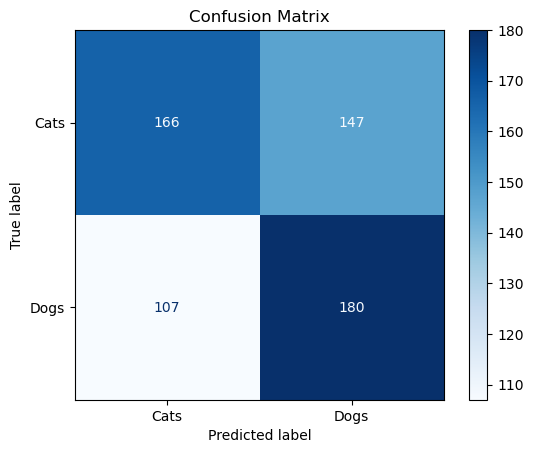

In [6]:
# Compute Predictions
y_pred = svm_model.predict(X_test_scaled)

# Print Text Metrics Summary
print(f"Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report Table:")
print(classification_report(y_test, y_pred, target_names=["Cats", "Dogs"]))

# Render Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Cats", "Dogs"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


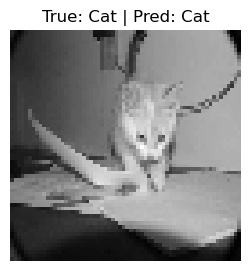

In [7]:
# Grab a random image from the test set to display the prediction visually
random_index = np.random.randint(0, len(X_test))
sample_image_flattened = X_test[random_index]
true_label = y_test[random_index]
predicted_label = y_pred[random_index]

# Reshape back to image format (64x64) for Matplotlib rendering
sample_image = sample_image_flattened.reshape(IMG_SIZE, IMG_SIZE)

display_categories = ["Cat", "Dog"]
plt.figure(figsize=(3, 3))
plt.imshow(sample_image, cmap='gray')
plt.title(f"True: {display_categories[true_label]} | Pred: {display_categories[predicted_label]}")
plt.axis('off')
plt.show()


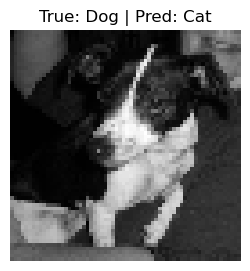

In [8]:
# Grab a completely new random image from the test set
new_random_index = np.random.randint(0, len(X_test))
new_sample_flattened = X_test[new_random_index]
new_true_label = y_test[new_random_index]
new_predicted_label = y_pred[new_random_index]

# Reshape the 1D feature array back to 2D image coordinates (64x64)
new_sample_image = new_sample_flattened.reshape(IMG_SIZE, IMG_SIZE)

# Render the visual result using Matplotlib
display_categories = ["Cat", "Dog"]
plt.figure(figsize=(3, 3))
plt.imshow(new_sample_image, cmap='gray')
plt.title(f"True: {display_categories[new_true_label]} | Pred: {display_categories[new_predicted_label]}")
plt.axis('off')
plt.show()
